In [7]:
import pandas as pd
import pm4py
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [8]:
df = pd.read_csv("../data/bpi-challenge-2017/bpi_2017_cleaned.csv")

In [9]:
df.head(5)

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df['time:timestamp'] = pd.to_datetime(pm_csv['time:timestamp'], format = 'mixed')
print(len(df))

1202267


- Phân loại single-offer và Multi offer

offer_type
Single-offer    22950
Multi-offer      8559
Name: count, dtype: int64


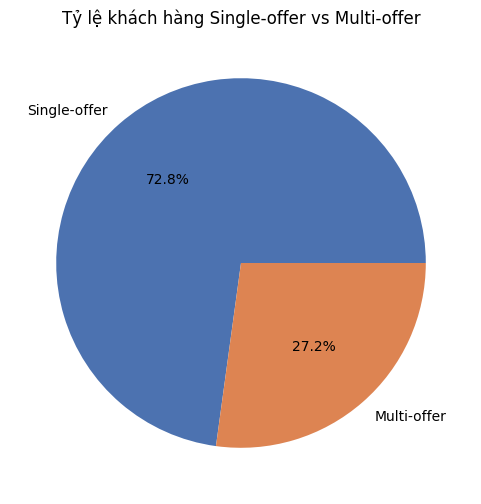

In [11]:
# Lọc các sự kiện tạo offer
offers_created = df[df['concept:name'] == 'O_Create Offer']

# Đếm số lượng offer cho mỗi case
offer_counts = offers_created.groupby('case:concept:name').size().reset_index(name='offer_count')

# Phân loại thành Single-offer (1 offer) và Multi-offer (>1 offer)
offer_counts['offer_type'] = np.where(offer_counts['offer_count'] == 1, 'Single-offer', 'Multi-offer')

# Xem phân bổ số lượng hồ sơ theo từng nhóm
print(offer_counts['offer_type'].value_counts())

# Vẽ biểu đồ tròn phân bổ
plt.figure(figsize=(6, 6))
offer_counts['offer_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'])
plt.title('Tỷ lệ khách hàng Single-offer vs Multi-offer')
plt.ylabel('')
plt.show()


So sánh Tỷ lệ chuyển đổi (Acceptance Rate):
- Một hồ sơ được coi là thành công (chấp nhận offer) nếu nó đi qua trạng thái O_Accepted

,offer_type,acceptance_rate
0,Multi-offer,0.590022
1,Single-offer,0.530632


C:\Users\Admin\AppData\Local\Temp\ipykernel_5220\4229751460.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=conversion_rate, x='offer_type', y='acceptance_rate', palette='viridis')


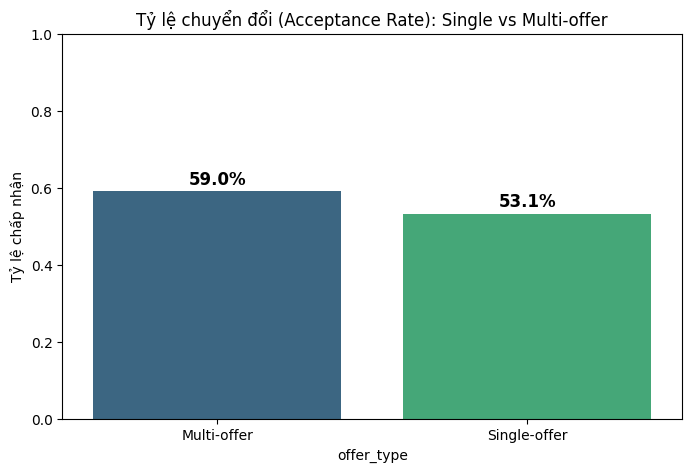

In [12]:
# Một case được coi là đã chốt deal nếu chứa sự kiện 'O_Accepted'
accepted_cases = df[df['concept:name'] == 'O_Accepted']['case:concept:name'].unique()

# Đánh dấu True/False cho các case thành công
offer_counts['is_accepted'] = offer_counts['case:concept:name'].isin(accepted_cases)

# Tính tỷ lệ chuyển đổi (Acceptance Rate)
conversion_rate = offer_counts.groupby('offer_type')['is_accepted'].mean().reset_index()
conversion_rate.rename(columns={'is_accepted': 'acceptance_rate'}, inplace=True)

display(conversion_rate)

# Vẽ biểu đồ so sánh Tỷ lệ chuyển đổi
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=conversion_rate, x='offer_type', y='acceptance_rate', palette='viridis')
plt.title('Tỷ lệ chuyển đổi (Acceptance Rate): Single vs Multi-offer')
plt.ylabel('Tỷ lệ chấp nhận')
plt.ylim(0, 1)

# Hiển thị % trên đầu cột
for i, rate in enumerate(conversion_rate['acceptance_rate']):
    ax.text(i, rate + 0.02, f'{rate:.1%}', ha='center', fontsize=12, fontweight='bold')
    
plt.show()


Phân tích Hành vi - Số lần bị yêu cầu bổ sung hồ sơ (A_Incomplete)
- Giả thuyết đặt ra là: khách hàng nhận được nhiều offer có thể là do quá trình thương lượng phức tạp hơn, hoặc hồ sơ có vấn đề khiến họ phải nộp đi nộp lại thông tin (Sự kiện A_Incomplete)

C:\Users\Admin\AppData\Local\Temp\ipykernel_5220\17904419.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=avg_incomplete, x='offer_type', y='incomplete_count', palette='muted')


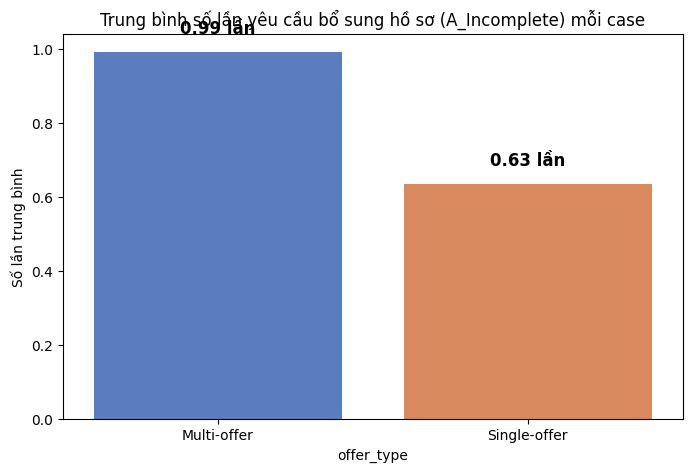

In [13]:
# Đếm số lần yêu cầu bổ sung hồ sơ (A_Incomplete) của từng case
incomplete_counts = df[df['concept:name'] == 'A_Incomplete'].groupby('case:concept:name').size().reset_index(name='incomplete_count')

# Merge vào bảng phân tích
offer_counts = offer_counts.merge(incomplete_counts, on='case:concept:name', how='left')
# Các case không có A_Incomplete sẽ là NaN -> điền 0
offer_counts['incomplete_count'] = offer_counts['incomplete_count'].fillna(0)

# Tính trung bình số lần Incomplete theo từng nhóm
avg_incomplete = offer_counts.groupby('offer_type')['incomplete_count'].mean().reset_index()

# Trực quan hóa
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=avg_incomplete, x='offer_type', y='incomplete_count', palette='muted')
plt.title('Trung bình số lần yêu cầu bổ sung hồ sơ (A_Incomplete) mỗi case')
plt.ylabel('Số lần trung bình')

for i, count in enumerate(avg_incomplete['incomplete_count']):
    ax.text(i, count + 0.05, f'{count:.2f} lần', ha='center', fontsize=12, fontweight='bold')

plt.show()


1. Sự "phiền hà" của quy trình (Process Friction) đi kèm với Multi-offer
Dữ liệu: Khách hàng nhận Multi-offer bị yêu cầu bổ sung hồ sơ (A_Incomplete) trung bình 0.99 lần/case, cao gấp rưỡi (khoảng 1.5 lần) so với nhóm Single-offer (0.63 lần/case).
Nhận xét: Điều này phản ánh sự thật rằng quá trình thương lượng lại, hoặc các hồ sơ khó/phức tạp thường đi kèm với việc thiếu sót giấy tờ hoặc sai lệch thông tin. Nó tạo ra "process friction" (sự cản trở quy trình), khiến nhân viên ngân hàng tốn nhiều công sức hơn (phải tạo mới offer, liên hệ lại khách hàng để bổ sung giấy tờ).
2. Sự đánh đổi xứng đáng: "Níu kéo" khách hàng thành công
Dữ liệu: Dù quy trình phiền hà hơn, tỷ lệ chốt deal (Acceptance Rate) của nhóm Multi-offer lại đạt 59.0%, cao hơn đáng kể so với nhóm Single-offer (53.1%).
Nhận xét: Đội ngũ Sale/Tín dụng của ngân hàng đang làm rất tốt! Việc chủ động tạo ra các offer thứ 2, thứ 3 (có thể là điều chỉnh lãi suất, thay đổi số tiền vay cho phù hợp với khả năng tài chính của khách) thực sự đã giúp "níu kéo" khách hàng. Thay vì từ chối thẳng thừng một hồ sơ chưa đạt chuẩn, việc linh hoạt đưa ra Multi-offer giúp ngân hàng tăng tỷ lệ chuyển đổi thêm gần 6%.


### Phân nhóm các loại offers

,offer_group,acceptance_rate,total_cases
0,1,0.530632,22950
1,2,0.573883,6578
2,3,0.655786,1348
3,4+,0.617694,633


C:\Users\Admin\AppData\Local\Temp\ipykernel_5220\2055000540.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=detailed_conversion, x='offer_group', y='acceptance_rate', palette='Blues_d')


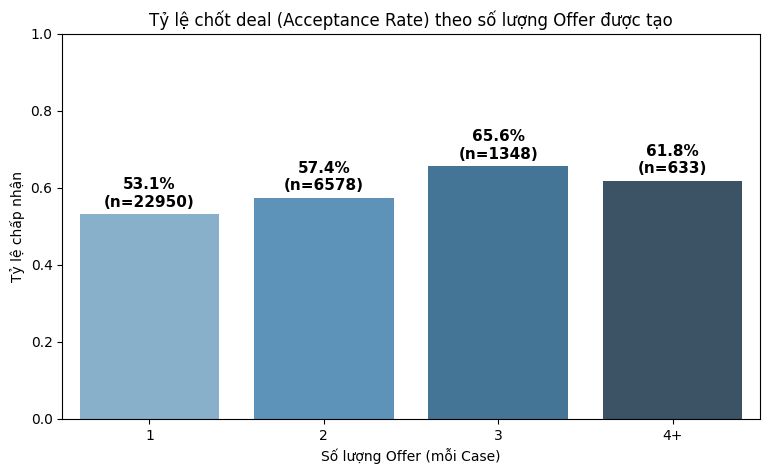

In [14]:
# --- Hỗ trợ đề xuất 1: Khuyến khích linh hoạt Offer ---

# Phân nhóm số lượng offer: 1, 2, 3, và "4+"
offer_counts['offer_group'] = offer_counts['offer_count'].apply(lambda x: str(x) if x <= 3 else '4+')

# Tính Acceptance Rate theo từng nhóm số lượng offer
detailed_conversion = offer_counts.groupby('offer_group')['is_accepted'].agg(['mean', 'count']).reset_index()
detailed_conversion.rename(columns={'mean': 'acceptance_rate', 'count': 'total_cases'}, inplace=True)

display(detailed_conversion)

# Trực quan hóa
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=detailed_conversion, x='offer_group', y='acceptance_rate', palette='Blues_d')
plt.title('Tỷ lệ chốt deal (Acceptance Rate) theo số lượng Offer được tạo')
plt.ylabel('Tỷ lệ chấp nhận')
plt.xlabel('Số lượng Offer (mỗi Case)')
plt.ylim(0, 1)

# Hiển thị text trên cột
for i, row in detailed_conversion.iterrows():
    rate = row['acceptance_rate']
    cases = row['total_cases']
    ax.text(i, rate + 0.02, f'{rate:.1%}\n(n={cases})', ha='center', fontsize=11, fontweight='bold')

plt.show()


,incomplete_status,throughput_days
0,Phải bổ sung hồ sơ (>=1 Incomplete),20.757246
1,Đầy đủ hồ sơ ngay (0 Incomplete),22.937945


C:\Users\Admin\AppData\Local\Temp\ipykernel_5220\839765712.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=time_impact, x='incomplete_status', y='throughput_days', palette='Reds_r')


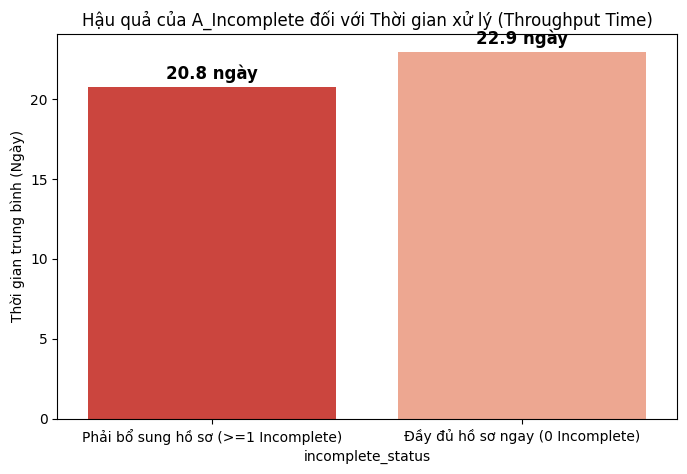

In [15]:
# --- Hỗ trợ đề xuất 2: Tối ưu hóa khâu thu thập hồ sơ ---

# Tính tổng thời gian xử lý (Throughput Time) của mỗi case
case_start = df.groupby('case:concept:name')['time:timestamp'].min()
case_end = df.groupby('case:concept:name')['time:timestamp'].max()

throughput_time = (case_end - case_start).dt.total_seconds() / (24 * 3600) # Tính bằng số Ngày
throughput_time = throughput_time.reset_index(name='throughput_days')

# Ghép thông tin throughput time vào bảng offer_counts
analysis_df = offer_counts.merge(throughput_time, on='case:concept:name', how='inner')

# Phân nhóm: Không bị Incomplete vs Bị Incomplete
analysis_df['incomplete_status'] = np.where(analysis_df['incomplete_count'] == 0, 
                                            'Đầy đủ hồ sơ ngay (0 Incomplete)', 
                                            'Phải bổ sung hồ sơ (>=1 Incomplete)')

# Tính thời gian trung bình
time_impact = analysis_df.groupby('incomplete_status')['throughput_days'].mean().reset_index()

display(time_impact)

# Trực quan hóa
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=time_impact, x='incomplete_status', y='throughput_days', palette='Reds_r')
plt.title('Hậu quả của A_Incomplete đối với Thời gian xử lý (Throughput Time)')
plt.ylabel('Thời gian trung bình (Ngày)')

for i, days in enumerate(time_impact['throughput_days']):
    ax.text(i, days + 0.5, f'{days:.1f} ngày', ha='center', fontsize=12, fontweight='bold')

plt.show()


,incomplete_status,throughput_days
0,Phải bổ sung hồ sơ (>=1 Incomplete),19.98401
1,Đầy đủ hồ sơ ngay (0 Incomplete),13.02755


C:\Users\Admin\AppData\Local\Temp\ipykernel_5220\642606808.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=time_impact, x='incomplete_status', y='throughput_days', palette='Reds_r')


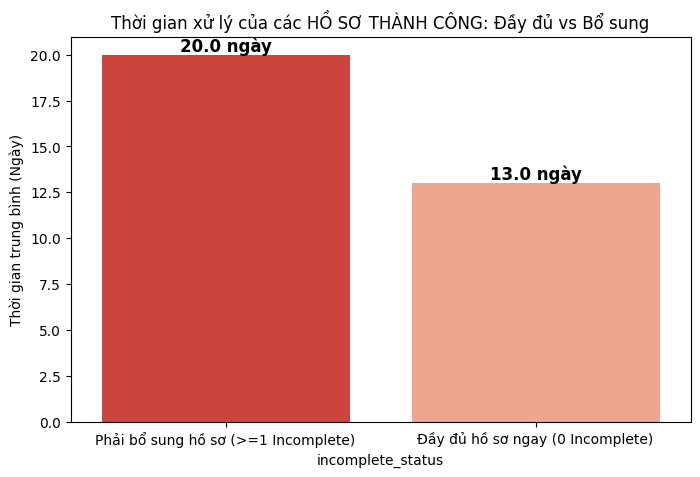

In [16]:
# Lọc: CHỈ tính thời gian xử lý cho các hồ sơ ĐƯỢC CHẤP NHẬN (thành công)
accepted_analysis = offer_counts[offer_counts['is_accepted'] == True].copy()

# Ghép thông tin throughput time vào bảng đã lọc
analysis_df = accepted_analysis.merge(throughput_time, on='case:concept:name', how='inner')

# Phân nhóm: Không bị Incomplete vs Bị Incomplete
analysis_df['incomplete_status'] = np.where(analysis_df['incomplete_count'] == 0, 
                                            'Đầy đủ hồ sơ ngay (0 Incomplete)', 
                                            'Phải bổ sung hồ sơ (>=1 Incomplete)')

# Tính thời gian trung bình
time_impact = analysis_df.groupby('incomplete_status')['throughput_days'].mean().reset_index()

display(time_impact)

# Vẽ lại biểu đồ
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=time_impact, x='incomplete_status', y='throughput_days', palette='Reds_r')
plt.title('Thời gian xử lý của các HỒ SƠ THÀNH CÔNG: Đầy đủ vs Bổ sung')
plt.ylabel('Thời gian trung bình (Ngày)')

for i, days in enumerate(time_impact['throughput_days']):
    ax.text(i, days + 0.2, f'{days:.1f} ngày', ha='center', fontsize=12, fontweight='bold')

plt.show()


TRONG QUÁ TRÌNH BỔ SUNG HỒ SƠ:
⏳ Khách hàng mất trung bình: 2.9 ngày để đi gom và nộp giấy tờ thiếu.
🏦 Ngân hàng mất trung bình: 1.7 ngày để review lại đống giấy tờ đó.


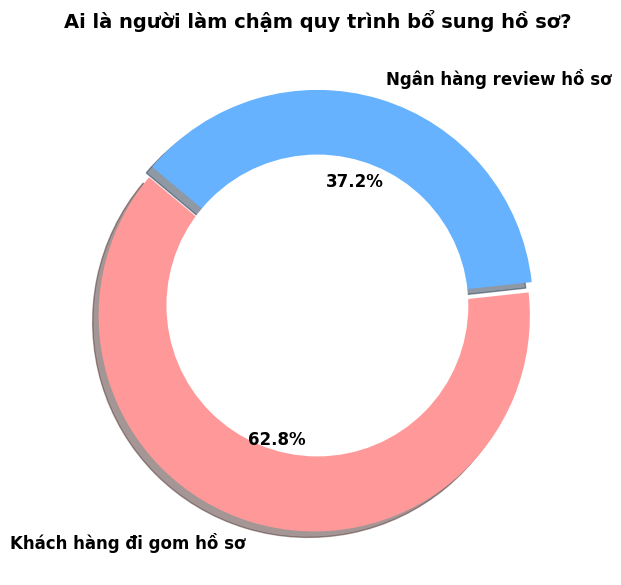

In [17]:
# --- Cell 7: Bóc tách Thời gian Khách hàng ngâm hồ sơ vs Ngân hàng xử lý ---

# Lọc chỉ lấy các sự kiện liên quan đến trạng thái hồ sơ (Application)
status_events = df[df['concept:name'].isin(['A_Incomplete', 'A_Validating', 'A_Pending', 'A_Accepted', 'A_Denied', 'A_Cancelled'])].copy()
status_events = status_events.sort_values(by=['case:concept:name', 'time:timestamp'])

# Tính thời gian giữa các bước (Dùng hàm shift để lấy thời gian của sự kiện tiếp theo)
status_events['next_event'] = status_events.groupby('case:concept:name')['concept:name'].shift(-1)
status_events['next_time'] = status_events.groupby('case:concept:name')['time:timestamp'].shift(-1)

# Tính khoảng thời gian giữa 2 sự kiện liên tiếp (bằng Ngày)
status_events['duration_days'] = (status_events['next_time'] - status_events['time:timestamp']).dt.total_seconds() / (24 * 3600)

# 1. Thời gian Khách hàng ngâm hồ sơ (Từ A_Incomplete -> A_Validating)
customer_delay = status_events[
    (status_events['concept:name'] == 'A_Incomplete') & 
    (status_events['next_event'] == 'A_Validating')
]['duration_days'].mean()

# 2. Thời gian Ngân hàng xử lý lại hồ sơ bổ sung (Từ A_Validating -> Bất kỳ trạng thái nào tiếp theo)
bank_delay = status_events[
    (status_events['concept:name'] == 'A_Validating')
]['duration_days'].mean()

print(f"TRONG QUÁ TRÌNH BỔ SUNG HỒ SƠ:")
print(f"⏳ Khách hàng mất trung bình: {customer_delay:.1f} ngày để đi gom và nộp giấy tờ thiếu.")
print(f"🏦 Ngân hàng mất trung bình: {bank_delay:.1f} ngày để review lại đống giấy tờ đó.")

# Trực quan hóa bằng biểu đồ Donut Chart (Bánh vòng)
plt.figure(figsize=(7, 7))
labels = ['Khách hàng đi gom hồ sơ', 'Ngân hàng review hồ sơ']
sizes = [customer_delay, bank_delay]
colors = ['#FF9999', '#66B2FF']
explode = (0.05, 0)

plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', 
        shadow=True, startangle=140, textprops={'fontsize': 12, 'weight': 'bold'})

# Vẽ vòng tròn trắng ở giữa để tạo thành Donut Chart
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Ai là người làm chậm quy trình bổ sung hồ sơ?', fontsize=14, fontweight='bold')
plt.show()
